# Extended Evaluation: Homogeneous vs Heterogeneous Server Configurations

This notebook compares DRL pricing performance between:
- **Homogeneous**: All servers have identical specifications
- **Heterogeneous**: Servers have varied specifications (Class A/B/C)

The goal is to validate that topology rankings remain stable under more realistic heterogeneous conditions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from os import listdir
from os.path import join, exists, isdir
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Data Loading

In [2]:
import xml.etree.ElementTree as ET

def load_server_class_mapping(xml_path):
    """Load server ID to class mapping from XML file"""
    server_classes = {}
    if not exists(xml_path):
        return server_classes
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for dc in root.findall('datacenter'):
            name = dc.get('name')
            server_id = int(''.join(filter(str.isdigit, name)))
            server_class_elem = dc.find('serverClass')
            if server_class_elem is not None and server_class_elem.text in ['A', 'B', 'C']:
                server_classes[server_id] = server_class_elem.text
    except Exception as e:
        print(f"Error loading XML {xml_path}: {e}")
    return server_classes

# Pre-load all server class mappings from XML files
SERVER_CLASS_MAPS = {
    'C_20_hetero': load_server_class_mapping('../EISim/EISim_settings/revision/settings_C_20servers_hetero/edge_datacenters.xml'),
    'H_20_hetero': load_server_class_mapping('../EISim/EISim_settings/revision/settings_H_20servers_hetero/edge_datacenters.xml'),
    'D_20_hetero': load_server_class_mapping('../EISim/EISim_settings/revision/settings_D_20servers_hetero/edge_datacenters.xml'),
    'C_100_hetero': load_server_class_mapping('../EISim/EISim_settings/revision/settings_C_100servers_hetero/edge_datacenters.xml'),
    'H_100_hetero': load_server_class_mapping('../EISim/EISim_settings/revision/settings_H_100servers_hetero/edge_datacenters.xml'),
    'D_100_hetero': load_server_class_mapping('../EISim/EISim_settings/revision/settings_D_100servers_hetero/edge_datacenters.xml'),
}

print("Server class mappings loaded:")
for key, mapping in SERVER_CLASS_MAPS.items():
    if mapping:
        from collections import Counter
        dist = Counter(mapping.values())
        print(f"  {key}: {len(mapping)} servers - A:{dist.get('A',0)}, B:{dist.get('B',0)}, C:{dist.get('C',0)}")

def get_agent_number_from_name(name):
    try:
        return int(name[-3:])
    except:
        try:
            return int(name[-2:])
        except:
            try:
                return int(name[-1])
            except:
                return 0

def parse_all_results(output_folder):
    results = {}
    if not exists(output_folder):
        print(f"Warning: Folder not found: {output_folder}")
        return results
    
    # Determine which server class map to use based on folder name
    is_hetero = output_folder.endswith('_hetero') or output_folder.endswith('_hetero/')
    total_servers = 20 if '20servers' in output_folder else 100
    
    # Extract topology letter from folder name
    topo_letter = None
    for letter in ['C', 'H', 'D']:
        if f'output_{letter}_' in output_folder:
            topo_letter = letter
            break
    
    # Get the correct server class mapping
    if is_hetero and topo_letter:
        map_key = f'{topo_letter}_{total_servers}_hetero'
        server_class_map = SERVER_CLASS_MAPS.get(map_key, {})
    else:
        server_class_map = {}
    
    episode_folders = sorted([f for f in listdir(output_folder) if isdir(join(output_folder, f))])
    
    for efolder in episode_folders:
        path_to_efolder = join(output_folder, efolder)
        parallel_files = sorted([f for f in listdir(path_to_efolder) 
                                  if f.startswith('Parallel_simulation_') and f.endswith('.csv')])
        
        for pfile in parallel_files:
            try:
                sim_data = pd.read_csv(join(path_to_efolder, pfile))
            except Exception as e:
                print(f"Error reading {pfile}: {e}")
                continue
            
            for i in range(len(sim_data)):
                row = sim_data.iloc[i]
                try:
                    control = row['Orchestration algorithm']
                    architecture = row['Orchestration architecture']
                    device_count = int(row['Edge devices count'])
                    n_tasks = row['Number of generated tasks'] - row.get('Tasks not generated due to the death of devices', 0)
                    
                    if control not in results:
                        results[control] = {}
                    if device_count not in results[control]:
                        results[control][device_count] = []
                    
                    edge_total = row['Total tasks executed (Edge)']
                    mist_total = row['Total tasks executed (Mist)']
                    
                    log_folder = f"Pricelogs_scenario_{control}_{architecture}_{device_count}"
                    path_to_log = join(path_to_efolder, log_folder)
                    cum_return = 0
                    server_tasks = {'A': 0, 'B': 0, 'C': 0}
                    
                    if exists(path_to_log):
                        for lf in listdir(path_to_log):
                            if lf.endswith('.csv'):
                                try:
                                    agent_data = pd.read_csv(join(path_to_log, lf))
                                    cum_return += agent_data['CumulativeProfit'].iat[-1]
                                    
                                    if is_hetero and 'State' in agent_data.columns:
                                        def parse_state1(s):
                                            try:
                                                return float(s.strip('[]').split(';')[1].strip())
                                            except:
                                                return 0.0
                                        tasks_proxy = agent_data['State'].apply(parse_state1).sum()
                                        
                                        # Extract server ID from filename (e.g., "dc1_log.csv" -> 1)
                                        server_id_str = ''.join(filter(str.isdigit, lf.split('_')[0]))
                                        if server_id_str:
                                            server_id = int(server_id_str)
                                            # Use XML-based mapping instead of sequential assumption
                                            stype = server_class_map.get(server_id, 'A')
                                            server_tasks[stype] += tasks_proxy
                                except Exception as e:
                                    pass
                    
                    offload_rate = 100 * row['Total tasks executed (Edge)'] / n_tasks if n_tasks > 0 else 0
                    device_success_rate = 100 * row['Tasks successfully executed (Mist)'] / mist_total if mist_total > 0 else 0
                    net_traffic = row.get(' Total network traffic (MBytes)', 0) 
                    avg_net_usage = net_traffic / edge_total if edge_total > 0 else 0
                    
                    results[control][device_count].append({
                        'episode': efolder,
                        'avgExecDelay': row['Average execution delay (s)'],
                        'tasksFailedDelay': 100 * row['Tasks failed (delay)'] / n_tasks if n_tasks > 0 else 0,
                        'edgeSuccessRate': 100 * row['Tasks successfully executed (Edge)'] / edge_total if edge_total > 0 else 0,
                        'offloadRate': offload_rate,
                        'deviceSuccessRate': device_success_rate,
                        'avgNetUsage': avg_net_usage,
                        'avgCpuEdge': row['Average CPU usage (Edge) (%)'],
                        'avgEnergyEdge': row['Average Edge energy consumption (Wh/Data center)'],
                        'cumulativeReturn': cum_return,
                        'serverTasksA': server_tasks['A'],
                        'serverTasksB': server_tasks['B'],
                        'serverTasksC': server_tasks['C']
                    })
                except Exception as e:
                    print(f"Error processing row in {pfile}: {e}")
    
    return results

Server class mappings loaded:
  C_20_hetero: 20 servers - A:6, B:8, C:6
  H_20_hetero: 20 servers - A:6, B:8, C:6
  D_20_hetero: 20 servers - A:6, B:8, C:6
  C_100_hetero: 100 servers - A:20, B:50, C:30
  H_100_hetero: 100 servers - A:20, B:50, C:30
  D_100_hetero: 100 servers - A:20, B:50, C:30


In [3]:
path_homo = '../EISim/EISim_output/revision/nayreed/'
path_hetero = '../EISim/EISim_output/revision/'

data = {
    'homo_20': {
        'C': parse_all_results(path_homo + 'output_C_20servers_homo'),
        'H': parse_all_results(path_homo + 'output_H_20servers_homo'),
        'D': parse_all_results(path_homo + 'output_D_20servers_homo')
    },
    'homo_100': {
        'C': parse_all_results(path_homo + 'output_C_100servers_homo'),
        'H': parse_all_results(path_homo + 'output_H_100servers_homo'),
        'D': parse_all_results(path_homo + 'output_D_100servers_homo')
    },
    'hetero_20': {
        'C': parse_all_results(path_hetero + 'output_C_20servers_hetero'),
        'H': parse_all_results(path_hetero + 'output_H_20servers_hetero'),
        'D': parse_all_results(path_hetero + 'output_D_20servers_hetero')
    },
    'hetero_100': {
        'C': parse_all_results(path_hetero + 'output_C_100servers_hetero'),
        'H': parse_all_results(path_hetero + 'output_H_100servers_hetero'),
        'D': parse_all_results(path_hetero + 'output_D_100servers_hetero')
    }
}

print("Data loaded successfully!")

Data loaded successfully!


## 2. Data Validation

Check if homogeneous and heterogeneous data are actually different

In [4]:
def extract_metric(data_dict, topology_key, metric='cumulativeReturn'):
    result = {}
    topo_data = data_dict.get(topology_key, {})
    for topo_name, devices in topo_data.items():
        for dc, samples in devices.items():
            key = f"{topo_name}_{dc}"
            result[key] = [s[metric] for s in samples]
    return result

print("="*80)
print("DATA VALIDATION: Checking if Homo vs Hetero data are actually different")
print("="*80)

for server_count in ['20', '100']:
    print(f"\n--- {server_count} Servers ---")
    homo_key = f'homo_{server_count}'
    hetero_key = f'hetero_{server_count}'
    
    for topo_letter in ['C', 'H', 'D']:
        topo_name = {'C': 'CENTRALIZED', 'H': 'HYBRID', 'D': 'DECENTRALIZED'}[topo_letter]
        
        homo_topo = data[homo_key].get(topo_letter, {})
        hetero_topo = data[hetero_key].get(topo_letter, {})
        
        for topo_inner, devices in homo_topo.items():
            for dc, homo_samples in devices.items():
                hetero_samples = hetero_topo.get(topo_inner, {}).get(dc, [])
                
                if homo_samples and hetero_samples:
                    homo_val = homo_samples[0]['cumulativeReturn']
                    hetero_val = hetero_samples[0]['cumulativeReturn']
                    is_same = abs(homo_val - hetero_val) < 1
                    status = "SAME DATA!" if is_same else "Different"
                    print(f"  {topo_name} {dc} devices: Homo={homo_val:,.0f}, Hetero={hetero_val:,.0f} -> {status}")

DATA VALIDATION: Checking if Homo vs Hetero data are actually different

--- 20 Servers ---
  CENTRALIZED 1000 devices: Homo=125,833,241, Hetero=159,580,876 -> Different
  CENTRALIZED 2000 devices: Homo=263,110,265, Hetero=267,157,018 -> Different
  CENTRALIZED 3000 devices: Homo=334,239,054, Hetero=344,398,589 -> Different
  CENTRALIZED 4000 devices: Homo=454,541,070, Hetero=466,665,351 -> Different
  HYBRID 1000 devices: Homo=51,405,472, Hetero=21,067,208 -> Different
  HYBRID 2000 devices: Homo=113,354,033, Hetero=95,836,496 -> Different
  HYBRID 3000 devices: Homo=176,881,811, Hetero=200,711,141 -> Different
  HYBRID 4000 devices: Homo=290,771,182, Hetero=302,902,540 -> Different
  DECENTRALIZED 1000 devices: Homo=57,205,962, Hetero=35,878,746 -> Different
  DECENTRALIZED 2000 devices: Homo=109,695,752, Hetero=109,963,028 -> Different
  DECENTRALIZED 3000 devices: Homo=193,003,687, Hetero=213,897,680 -> Different
  DECENTRALIZED 4000 devices: Homo=299,508,245, Hetero=307,816,683 ->

## 3. Build Comparison Table

In [5]:
def build_comparison_table(data, server_count, metric='cumulativeReturn'):
    homo_key = f'homo_{server_count}'
    hetero_key = f'hetero_{server_count}'

    rows = []
    topo_map = {'C': 'CENTRALIZED', 'H': 'HYBRID', 'D': 'DECENTRALIZED'}
    device_counts = [1000, 2000, 3000, 4000]

    for topo_letter in ['C', 'H', 'D']:
        topo_name = topo_map[topo_letter]

        homo_folder_data = data[homo_key].get(topo_letter, {})
        hetero_folder_data = data[hetero_key].get(topo_letter, {})

        # Get all inner_topo keys from both homo and hetero
        all_inner_topos = set(homo_folder_data.keys()) | set(hetero_folder_data.keys())

        for inner_topo in all_inner_topos:
            homo_devices = homo_folder_data.get(inner_topo, {})
            hetero_devices = hetero_folder_data.get(inner_topo, {})

            # Get all device counts from both
            all_dcs = set(homo_devices.keys()) | set(hetero_devices.keys())
            # Also include standard device counts to ensure consistency
            all_dcs = all_dcs | set(device_counts)

            for dc in sorted(all_dcs):
                homo_samples = homo_devices.get(dc, [])
                hetero_samples = hetero_devices.get(dc, [])

                # Skip if neither has data for this device count
                if not homo_samples and not hetero_samples:
                    continue

                if homo_samples:
                    homo_vals = [s[metric] for s in homo_samples]
                    homo_mean = np.mean(homo_vals)
                    homo_n = len(homo_vals)
                else:
                    homo_mean = np.nan
                    homo_n = 0

                if hetero_samples:
                    hetero_vals = [s[metric] for s in hetero_samples]
                    hetero_mean = np.mean(hetero_vals)
                    hetero_n = len(hetero_vals)
                else:
                    hetero_mean = np.nan
                    hetero_n = 0

                if homo_mean != 0 and not np.isnan(homo_mean):
                    pct_change = (hetero_mean - homo_mean) / homo_mean * 100
                else:
                    pct_change = np.nan

                is_same = abs(homo_mean - hetero_mean) < 1 if not np.isnan(homo_mean) and not np.isnan(hetero_mean) else False

                # Mark missing data
                data_issue = ''
                if is_same:
                    data_issue = 'SAME DATA'
                elif homo_n == 0:
                    data_issue = 'NO HOMO'
                elif hetero_n == 0:
                    data_issue = 'NO HETERO'

                rows.append({
                    'Topology': topo_name,
                    'Devices': dc,
                    'Homo': homo_mean,
                    'Homo_N': homo_n,
                    'Hetero': hetero_mean,
                    'Hetero_N': hetero_n,
                    'Change_%': pct_change,
                    'Data_Issue': data_issue
                })

    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame(columns=['Topology', 'Devices', 'Homo', 'Homo_N', 'Hetero', 'Hetero_N', 'Change_%', 'Data_Issue'])
    return df

In [6]:
print("="*100)
print("CUMULATIVE RETURN COMPARISON: 20 Servers")
print("="*100)
print("\nShows ESP profit under homogeneous vs heterogeneous server configurations")

table_20 = build_comparison_table(data, '20', 'cumulativeReturn')
table_20_display = table_20.copy()
table_20_display['Homo'] = table_20_display['Homo'].apply(lambda x: f"{x:,.0f}" if not np.isnan(x) else 'N/A')
table_20_display['Hetero'] = table_20_display['Hetero'].apply(lambda x: f"{x:,.0f}" if not np.isnan(x) else 'N/A')
table_20_display['Change_%'] = table_20_display['Change_%'].apply(lambda x: f"{x:+.1f}%" if not np.isnan(x) else 'N/A')
display(table_20_display)

CUMULATIVE RETURN COMPARISON: 20 Servers

Shows ESP profit under homogeneous vs heterogeneous server configurations


,Topology,Devices,Homo,Homo_N,Hetero,Hetero_N,Change_%,Data_Issue
0,CENTRALIZED,1000,"99,497,757",5,"105,544,543",5,+6.1%,
1,CENTRALIZED,2000,"186,248,082",5,"194,444,836",5,+4.4%,
2,CENTRALIZED,3000,"289,979,059",5,"299,059,475",5,+3.1%,
3,CENTRALIZED,4000,"378,345,683",5,"390,004,936",5,+3.1%,
4,HYBRID,1000,"52,348,272",5,"21,709,600",5,-58.5%,
5,HYBRID,2000,"114,900,499",5,"91,583,762",5,-20.3%,
6,HYBRID,3000,"179,911,038",5,"199,914,920",5,+11.1%,
7,HYBRID,4000,"290,652,802",5,"301,591,451",5,+3.8%,
8,DECENTRALIZED,1000,"51,703,919",5,"33,723,199",4,-34.8%,
9,DECENTRALIZED,2000,"109,155,231",5,"109,071,948",5,-0.1%,


In [7]:
print("="*100)
print("CUMULATIVE RETURN COMPARISON: 100 Servers")
print("="*100)
print("\nShows ESP profit under homogeneous vs heterogeneous server configurations\n")

table_100 = build_comparison_table(data, '100', 'cumulativeReturn')
table_100_display = table_100.copy()
table_100_display['Homo'] = table_100_display['Homo'].apply(lambda x: f"{x:,.0f}" if not np.isnan(x) else 'N/A')
table_100_display['Hetero'] = table_100_display['Hetero'].apply(lambda x: f"{x:,.0f}" if not np.isnan(x) else 'N/A')
table_100_display['Change_%'] = table_100_display['Change_%'].apply(lambda x: f"{x:+.1f}%" if not np.isnan(x) else 'N/A')
display(table_100_display)

CUMULATIVE RETURN COMPARISON: 100 Servers

Shows ESP profit under homogeneous vs heterogeneous server configurations



,Topology,Devices,Homo,Homo_N,Hetero,Hetero_N,Change_%,Data_Issue
0,CENTRALIZED,1000,"71,072,397",5,"83,578,047",5,+17.6%,
1,CENTRALIZED,2000,"131,995,010",5,"147,270,385",5,+11.6%,
2,CENTRALIZED,3000,"207,707,329",5,"232,204,324",5,+11.8%,
3,CENTRALIZED,4000,"274,102,892",5,"304,210,866",5,+11.0%,
4,HYBRID,1000,"28,459,840",5,"34,754,784",5,+22.1%,
5,HYBRID,2000,"81,447,921",5,"91,736,563",5,+12.6%,
6,HYBRID,3000,"148,520,130",5,"171,250,300",5,+15.3%,
7,HYBRID,4000,"206,001,582",5,"244,240,409",5,+18.6%,
8,DECENTRALIZED,1000,"25,252,678",5,"21,480,169",5,-14.9%,
9,DECENTRALIZED,2000,"82,241,337",5,"93,516,687",5,+13.7%,


## 4. Multi-Metric Comparison

In [8]:
def build_multi_metric_table(data, server_count):
    metrics = ['cumulativeReturn', 'avgExecDelay', 'edgeSuccessRate', 'avgCpuEdge', 'avgEnergyEdge', 'tasksFailedDelay']
    metric_labels = {
        'cumulativeReturn': 'ESP Profit',
        'avgExecDelay': 'Exec Delay (s)',
        'edgeSuccessRate': 'Edge Success (%)',
        'avgCpuEdge': 'CPU Usage (%)',
        'avgEnergyEdge': 'Energy (Wh)',
        'tasksFailedDelay': 'Failed Tasks (%)'
    }
    
    rows = []
    homo_key = f'homo_{server_count}'
    hetero_key = f'hetero_{server_count}'
    topo_map = {'C': 'CENTRALIZED', 'H': 'HYBRID', 'D': 'DECENTRALIZED'}
    
    for topo_letter in ['C', 'H', 'D']:
        topo_name = topo_map[topo_letter]
        homo_folder = data[homo_key].get(topo_letter, {})
        hetero_folder = data[hetero_key].get(topo_letter, {})
        
        for inner_topo, devices in homo_folder.items():
            for dc in sorted(devices.keys()):
                homo_samples = devices.get(dc, [])
                hetero_samples = hetero_folder.get(inner_topo, {}).get(dc, [])
                
                row = {'Topology': topo_name, 'Devices': dc}
                
                for metric in metrics:
                    homo_vals = [s[metric] for s in homo_samples] if homo_samples else []
                    hetero_vals = [s[metric] for s in hetero_samples] if hetero_samples else []
                    
                    homo_mean = np.mean(homo_vals) if homo_vals else np.nan
                    hetero_mean = np.mean(hetero_vals) if hetero_vals else np.nan
                    
                    if homo_mean != 0 and not np.isnan(homo_mean):
                        pct = (hetero_mean - homo_mean) / homo_mean * 100
                    else:
                        pct = np.nan
                    
                    label = metric_labels[metric]
                    row[f'{label}_Homo'] = homo_mean
                    row[f'{label}_Hetero'] = hetero_mean
                    row[f'{label}_Change%'] = pct
                
                rows.append(row)
    
    return pd.DataFrame(rows)

print("="*100)
print("MULTI-METRIC COMPARISON: 100 Servers (Change % from Homo to Hetero)")
print("="*100)
print("\nPositive % = Hetero is higher, Negative % = Hetero is lower\n")

multi_100 = build_multi_metric_table(data, '100')
change_cols = [c for c in multi_100.columns if 'Change%' in c]
display(multi_100[['Topology', 'Devices'] + change_cols].round(1))

MULTI-METRIC COMPARISON: 100 Servers (Change % from Homo to Hetero)

Positive % = Hetero is higher, Negative % = Hetero is lower



,Topology,Devices,ESP Profit_Change%,Exec Delay (s)_Change%,Edge Success (%)_Change%,CPU Usage (%)_Change%,Energy (Wh)_Change%,Failed Tasks (%)_Change%
0,CENTRALIZED,1000,17.6,1.1,3.9,-74.8,-2.9,1.1
1,CENTRALIZED,2000,11.6,-0.1,10.2,-33.8,-2.4,-0.1
2,CENTRALIZED,3000,11.8,-0.1,11.4,-30.8,-2.4,-0.2
3,CENTRALIZED,4000,11.0,-0.1,9.8,-31.5,-2.4,-0.2
4,HYBRID,1000,22.1,-8.7,-45.1,34.5,2.3,29.4
5,HYBRID,2000,12.6,-1.6,-39.5,-8.1,-2.7,7.2
6,HYBRID,3000,15.3,-1.3,-13.2,15.7,-0.4,1.0
7,HYBRID,4000,18.6,0.3,-13.4,-11.9,-2.3,2.6
8,DECENTRALIZED,1000,-14.9,-25.4,-73.6,81.2,13.3,70.5
9,DECENTRALIZED,2000,13.7,-5.4,-46.9,28.5,10.7,17.0


## 5. Topology Rankings

In [9]:
def get_rankings(data, server_count):
    homo_key = f'homo_{server_count}'
    hetero_key = f'hetero_{server_count}'
    
    results = []
    device_counts = [1000, 2000, 3000, 4000]
    topo_map = {'C': 'CENTRALIZED', 'H': 'HYBRID', 'D': 'DECENTRALIZED'}
    
    for dc in device_counts:
        homo_scores = {}
        hetero_scores = {}
        
        for topo_letter in ['C', 'H', 'D']:
            topo_name = topo_map[topo_letter]
            
            homo_folder = data[homo_key].get(topo_letter, {})
            hetero_folder = data[hetero_key].get(topo_letter, {})
            
            for inner_topo, devices in homo_folder.items():
                samples = devices.get(dc, [])
                if samples:
                    homo_scores[topo_name] = np.mean([s['cumulativeReturn'] for s in samples])
            
            for inner_topo, devices in hetero_folder.items():
                samples = devices.get(dc, [])
                if samples:
                    hetero_scores[topo_name] = np.mean([s['cumulativeReturn'] for s in samples])
        
        if homo_scores:
            homo_rank = sorted(homo_scores.keys(), key=lambda x: homo_scores[x], reverse=True)
        else:
            homo_rank = []
        
        if hetero_scores:
            hetero_rank = sorted(hetero_scores.keys(), key=lambda x: hetero_scores[x], reverse=True)
        else:
            hetero_rank = []
        
        results.append({
            'Devices': dc,
            'Homo_Ranking': ' > '.join(homo_rank),
            'Hetero_Ranking': ' > '.join(hetero_rank),
            'Match': homo_rank == hetero_rank,
            'Best_Homo': homo_rank[0] if homo_rank else 'N/A',
            'Best_Hetero': hetero_rank[0] if hetero_rank else 'N/A'
        })
    
    return pd.DataFrame(results)

print("="*100)
print("TOPOLOGY RANKINGS BY ESP PROFIT")
print("="*100)
print("\nDoes the best topology remain the same under heterogeneous conditions?\n")

print("--- 20 Servers ---")
rank_20 = get_rankings(data, '20')
display(rank_20)

print("\n--- 100 Servers ---")
rank_100 = get_rankings(data, '100')
display(rank_100)

TOPOLOGY RANKINGS BY ESP PROFIT

Does the best topology remain the same under heterogeneous conditions?

--- 20 Servers ---


,Devices,Homo_Ranking,Hetero_Ranking,Match,Best_Homo,Best_Hetero
0,1000,CENTRALIZED > HYBRID > DECENTRALIZED,CENTRALIZED > DECENTRALIZED > HYBRID,False,CENTRALIZED,CENTRALIZED
1,2000,CENTRALIZED > HYBRID > DECENTRALIZED,CENTRALIZED > DECENTRALIZED > HYBRID,False,CENTRALIZED,CENTRALIZED
2,3000,CENTRALIZED > DECENTRALIZED > HYBRID,CENTRALIZED > DECENTRALIZED > HYBRID,True,CENTRALIZED,CENTRALIZED
3,4000,CENTRALIZED > DECENTRALIZED > HYBRID,CENTRALIZED > DECENTRALIZED > HYBRID,True,CENTRALIZED,CENTRALIZED



--- 100 Servers ---


,Devices,Homo_Ranking,Hetero_Ranking,Match,Best_Homo,Best_Hetero
0,1000,CENTRALIZED > HYBRID > DECENTRALIZED,CENTRALIZED > HYBRID > DECENTRALIZED,True,CENTRALIZED,CENTRALIZED
1,2000,CENTRALIZED > DECENTRALIZED > HYBRID,CENTRALIZED > DECENTRALIZED > HYBRID,True,CENTRALIZED,CENTRALIZED
2,3000,CENTRALIZED > DECENTRALIZED > HYBRID,CENTRALIZED > HYBRID > DECENTRALIZED,False,CENTRALIZED,CENTRALIZED
3,4000,CENTRALIZED > DECENTRALIZED > HYBRID,CENTRALIZED > DECENTRALIZED > HYBRID,True,CENTRALIZED,CENTRALIZED


## 6. Visualization

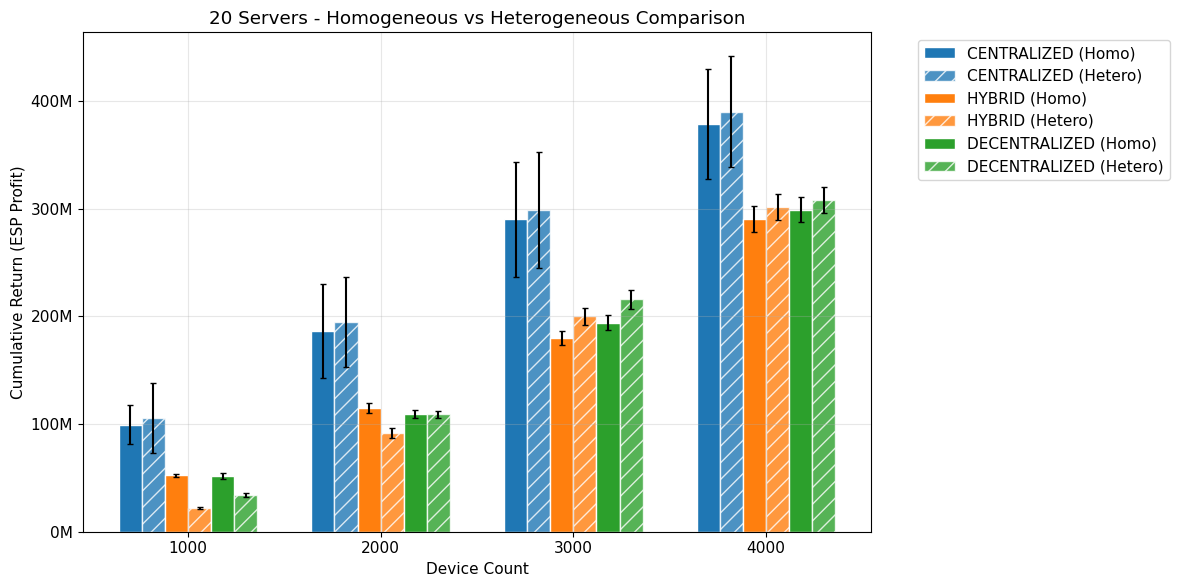

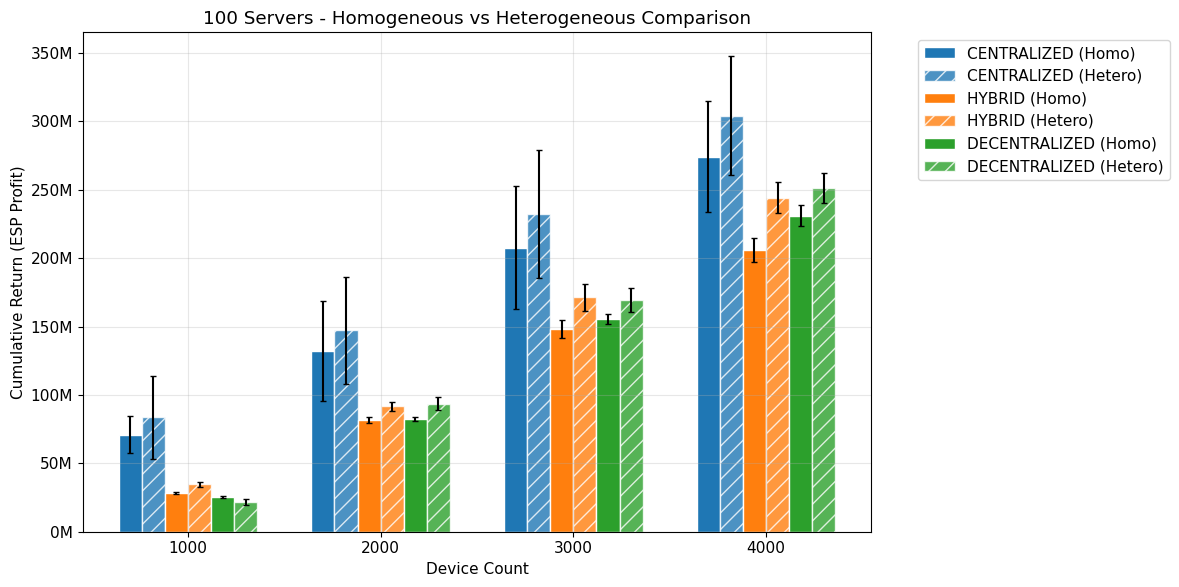

In [10]:
def plot_profit_comparison(data, server_count, title_suffix):
    homo_key = f'homo_{server_count}'
    hetero_key = f'hetero_{server_count}'
    
    device_counts = [1000, 2000, 3000, 4000]
    topo_map = {'C': 'CENTRALIZED', 'H': 'HYBRID', 'D': 'DECENTRALIZED'}
    colors = {'CENTRALIZED': 'tab:blue', 'HYBRID': 'tab:orange', 'DECENTRALIZED': 'tab:green'}
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(device_counts))
    width = 0.12  # width of a single bar
    num_bars = 6
    total_width = width * num_bars
    
    for i, topo_letter in enumerate(['C', 'H', 'D']):
        topo_name = topo_map[topo_letter]
        
        for j, (config_name, config_key, hatch, alpha) in enumerate([('Homo', homo_key, None, 1.0), ('Hetero', hetero_key, '//', 0.8)]):
            folder_data = data[config_key].get(topo_letter, {})
            
            means = []
            stds = []
            
            for dc in device_counts:
                vals = []
                for inner_topo, devices in folder_data.items():
                    samples = devices.get(dc, [])
                    vals.extend([s.get('cumulativeReturn', 0) for s in samples])
                
                if vals:
                    means.append(np.mean(vals))
                    stds.append(np.std(vals) if len(vals) > 1 else 0)
                else:
                    means.append(0)
                    stds.append(0)
            
            pos = x - (total_width / 2) + (i * 2 + j) * width + width/2
            label = f"{topo_name} ({config_name})"
            hatch_pattern = hatch if hatch else ''
            ax.bar(pos, means, width, yerr=stds, label=label, 
                   color=colors[topo_name], hatch=hatch_pattern, alpha=alpha, edgecolor='white', capsize=2)
    
    ax.set_xlabel('Device Count')
    ax.set_ylabel('Cumulative Return (ESP Profit)')
    ax.set_title(f'{title_suffix} - Homogeneous vs Heterogeneous Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(device_counts)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, p: f'{val/1e6:.0f}M'))
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    return fig

fig1 = plot_profit_comparison(data, '20', '20 Servers')
plt.savefig('profit_comparison_20servers.pdf', bbox_inches='tight')
plt.show()

fig2 = plot_profit_comparison(data, '100', '100 Servers')
plt.savefig('profit_comparison_100servers.pdf', bbox_inches='tight')
plt.show()


## 7. Key Findings Summary

In [11]:
print("="*100)
print("KEY FINDINGS SUMMARY")
print("="*100)

print("\n1. DATA VALIDATION ISSUES:")
print("-" * 50)
for server_count in ['20', '100']:
    table = build_comparison_table(data, server_count, 'cumulativeReturn')
    same_data = table[table['Data_Issue'] == 'SAME DATA']
    if len(same_data) > 0:
        print(f"   {server_count} Servers: {len(same_data)} scenarios have IDENTICAL homo/hetero data")
        print(f"   Affected: {same_data['Topology'].unique().tolist()}")
    else:
        print(f"   {server_count} Servers: All scenarios have different homo/hetero data (OK)")

print("\n2. RANKING STABILITY:")
print("-" * 50)
for server_count in ['20', '100']:
    rankings = get_rankings(data, server_count)
    matches = rankings['Match'].sum()
    total = len(rankings)
    print(f"   {server_count} Servers: {matches}/{total} device counts have same ranking")

print("\n3. AVERAGE PROFIT CHANGE (Hetero vs Homo):")
print("-" * 50)
for server_count in ['20', '100']:
    table = build_comparison_table(data, server_count, 'cumulativeReturn')
    valid = table[table['Data_Issue'] != 'SAME DATA']
    if len(valid) > 0:
        avg_change = valid['Change_%'].mean()
        print(f"   {server_count} Servers: {avg_change:+.1f}% average change")
    else:
        print(f"   {server_count} Servers: No valid scenarios for comparison")

KEY FINDINGS SUMMARY

1. DATA VALIDATION ISSUES:
--------------------------------------------------
   20 Servers: All scenarios have different homo/hetero data (OK)
   100 Servers: All scenarios have different homo/hetero data (OK)

2. RANKING STABILITY:
--------------------------------------------------
   20 Servers: 2/4 device counts have same ranking
   100 Servers: 3/4 device counts have same ranking

3. AVERAGE PROFIT CHANGE (Hetero vs Homo):
--------------------------------------------------
   20 Servers: -5.7% average change
   100 Servers: +11.4% average change


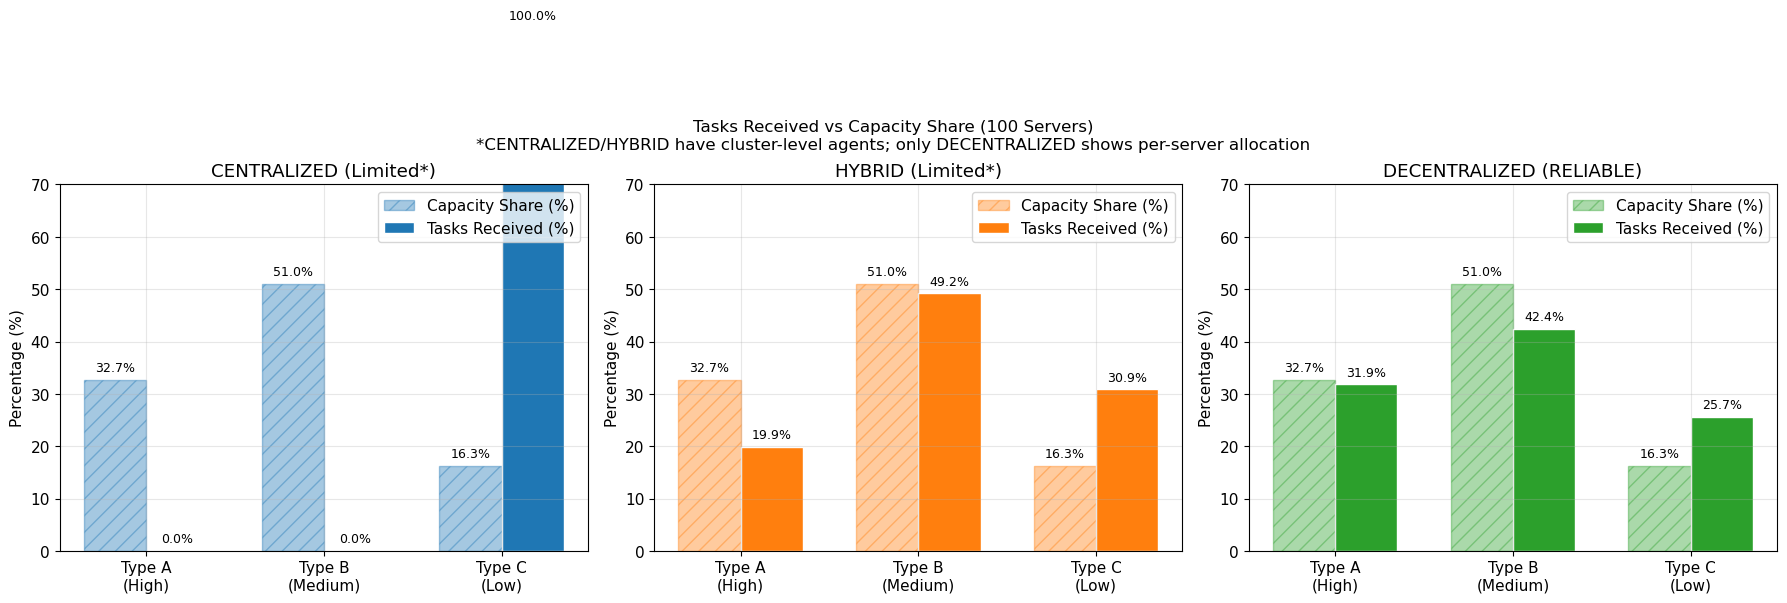


100 Servers - DECENTRALIZED (Reliable Data):
  Class A: Capacity=32.7%, Tasks=31.9%, Diff=-0.8%
  Class B: Capacity=51.0%, Tasks=42.4%, Diff=-8.6%
  Class C: Capacity=16.3%, Tasks=25.7%, Diff=+9.4%
  Ratio A:C - Capacity: 2.0:1, Tasks: 1.2:1


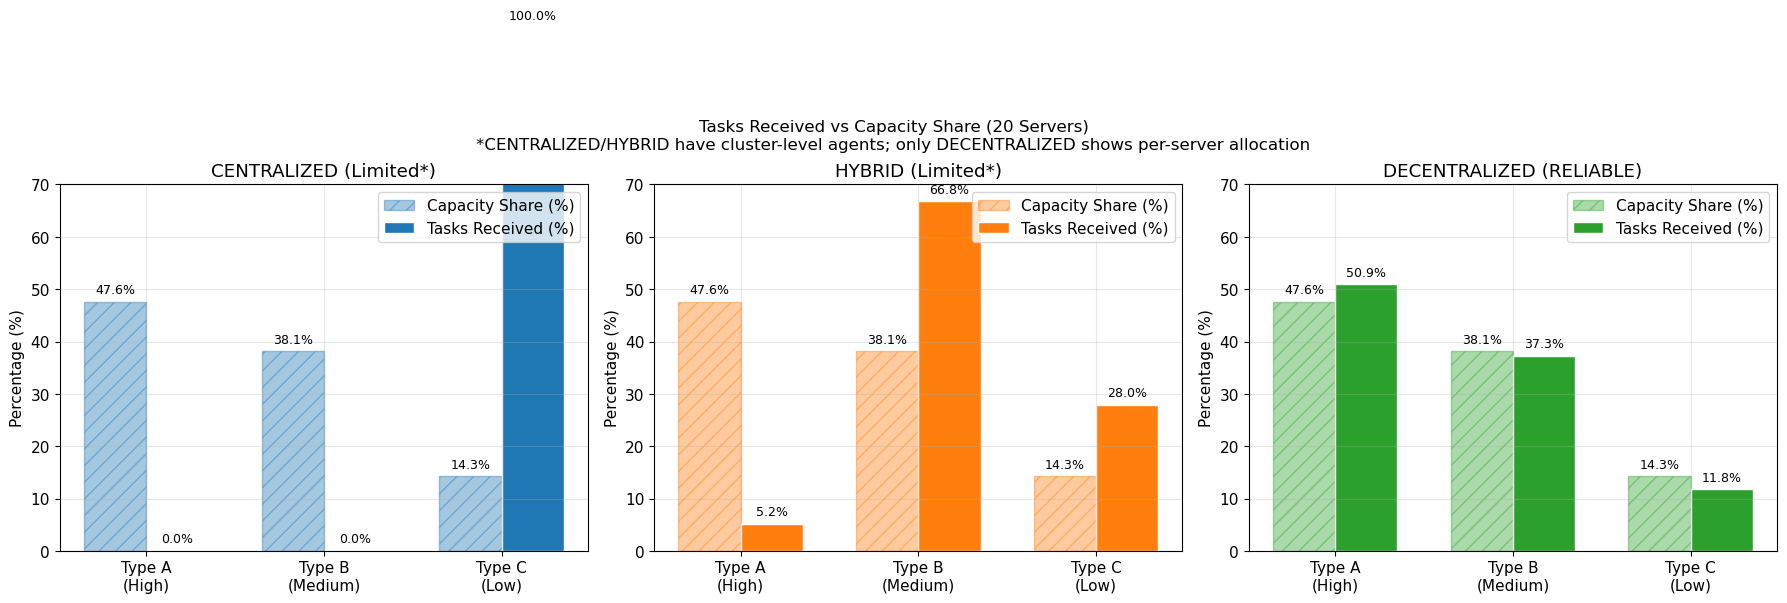


20 Servers - DECENTRALIZED (Reliable Data):
  Class A: Capacity=47.6%, Tasks=50.9%, Diff=+3.3%
  Class B: Capacity=38.1%, Tasks=37.3%, Diff=-0.8%
  Class C: Capacity=14.3%, Tasks=11.8%, Diff=-2.5%
  Ratio A:C - Capacity: 3.3:1, Tasks: 4.3:1


In [12]:
def plot_capacity_vs_allocations(data, server_count='100'):
    """
    Plot capacity share vs task allocation by server class.
    
    NOTE: Only DECENTRALIZED topology data is reliable because each server has its own
    pricing agent. CENTRALIZED has 1 agent for all servers, HYBRID has cluster-level agents,
    so their "task proxy" doesn't reflect per-server allocation.
    """
    import xml.etree.ElementTree as ET
    from collections import Counter
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    topo_map = {'C': 'CENTRALIZED', 'H': 'HYBRID', 'D': 'DECENTRALIZED'}
    colors = {'C': 'tab:blue', 'H': 'tab:orange', 'D': 'tab:green'}
    
    # Correct capacity shares from XML (MIPS-based)
    cap_shares = {'A': 32.7, 'B': 51.0, 'C': 16.3} if server_count=='100' else {'A': 47.6, 'B': 38.1, 'C': 14.3}
    
    # Load server class mappings from XML
    def load_server_class_mapping(xml_path):
        server_classes = {}
        if not exists(xml_path):
            return server_classes
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for dc in root.findall('datacenter'):
            name = dc.get('name')
            server_id = int(''.join(filter(str.isdigit, name)))
            server_class_elem = dc.find('serverClass')
            if server_class_elem is not None and server_class_elem.text in ['A', 'B', 'C']:
                server_classes[server_id] = server_class_elem.text
        return server_classes
    
    data_hetero = data[f'hetero_{server_count}']
    
    for idx, topo in enumerate(['C', 'H', 'D']):
        ax = axes[idx]
        
        # Load correct server class mapping for this topology
        xml_path = f'../EISim/EISim_settings/revision/settings_{topo}_{server_count}servers_hetero/edge_datacenters.xml'
        server_class_map = load_server_class_mapping(xml_path)
        
        folder_data = data_hetero.get(topo, {})
        
        # Re-calculate task allocation with correct mapping
        class_tasks = {'A': 0, 'B': 0, 'C': 0}
        
        output_path = f'../EISim/EISim_output/revision/output_{topo}_{server_count}servers_hetero'
        if exists(output_path):
            for efolder in listdir(output_path):
                path_to_efolder = join(output_path, efolder)
                if not isdir(path_to_efolder):
                    continue
                for item in listdir(path_to_efolder):
                    if item.startswith('Pricelogs_scenario_'):
                        log_folder = join(path_to_efolder, item)
                        if not isdir(log_folder):
                            continue
                        for lf in listdir(log_folder):
                            if lf.endswith('.csv'):
                                try:
                                    server_id_str = ''.join(filter(str.isdigit, lf.split('_')[0]))
                                    if not server_id_str:
                                        continue
                                    server_id = int(server_id_str)
                                    stype = server_class_map.get(server_id)
                                    if stype is None:
                                        continue
                                    agent_data = pd.read_csv(join(log_folder, lf))
                                    if 'State' in agent_data.columns:
                                        def parse_arrival(s):
                                            try:
                                                return float(s.strip('[]').split(';')[1].strip())
                                            except:
                                                return 0.0
                                        tasks_proxy = agent_data['State'].apply(parse_arrival).sum()
                                        class_tasks[stype] += tasks_proxy
                                except:
                                    pass
        
        total = sum(class_tasks.values())
        if total > 0:
            a_pct = (class_tasks['A'] / total) * 100
            b_pct = (class_tasks['B'] / total) * 100
            c_pct = (class_tasks['C'] / total) * 100
        else:
            a_pct = b_pct = c_pct = 0
            
        labels = ['Type A\n(High)', 'Type B\n(Medium)', 'Type C\n(Low)']
        shares = [cap_shares['A'], cap_shares['B'], cap_shares['C']]
        tasks = [a_pct, b_pct, c_pct]
        
        x = np.arange(len(labels))
        width = 0.35
        
        topo_color = colors[topo]
        
        bars1 = ax.bar(x - width/2, shares, width, label='Capacity Share (%)', color=topo_color, alpha=0.4, edgecolor=topo_color, hatch='//')
        bars2 = ax.bar(x + width/2, tasks, width, label='Tasks Received (%)', color=topo_color, edgecolor='white')
        
        # Add value labels on bars
        for bar, val in zip(bars1, shares):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
        for bar, val in zip(bars2, tasks):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
        
        ax.set_ylabel('Percentage (%)')
        ax.set_ylim(0, 70)
        
        # Mark reliability
        reliability = "RELIABLE" if topo == 'D' else "Limited*"
        ax.set_title(f'{topo_map[topo]} ({reliability})')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.legend(loc='upper right')
        
    plt.suptitle(f'Tasks Received vs Capacity Share ({server_count} Servers)\n*CENTRALIZED/HYBRID have cluster-level agents; only DECENTRALIZED shows per-server allocation', fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.savefig(f'capacity_vs_tasks_{server_count}servers.pdf', bbox_inches='tight')
    plt.show()
    
    # Print summary for DECENTRALIZED (the reliable one)
    print(f"\n{server_count} Servers - DECENTRALIZED (Reliable Data):")
    print(f"  Class A: Capacity={cap_shares['A']:.1f}%, Tasks={a_pct:.1f}%, Diff={a_pct-cap_shares['A']:+.1f}%")
    print(f"  Class B: Capacity={cap_shares['B']:.1f}%, Tasks={b_pct:.1f}%, Diff={b_pct-cap_shares['B']:+.1f}%")
    print(f"  Class C: Capacity={cap_shares['C']:.1f}%, Tasks={c_pct:.1f}%, Diff={c_pct-cap_shares['C']:+.1f}%")
    if c_pct > 0:
        print(f"  Ratio A:C - Capacity: {cap_shares['A']/cap_shares['C']:.1f}:1, Tasks: {a_pct/c_pct:.1f}:1")

plot_capacity_vs_allocations(data, '100')
plot_capacity_vs_allocations(data, '20')

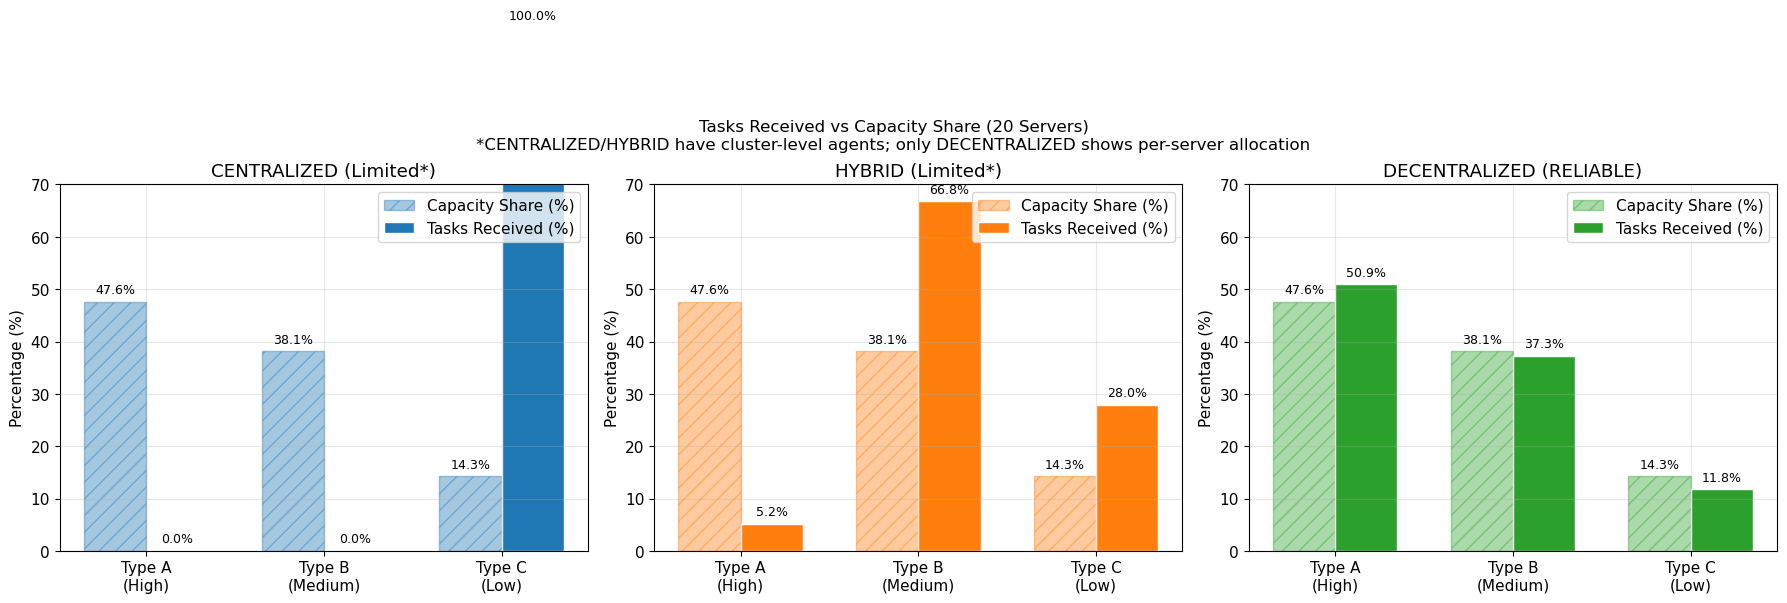


20 Servers - DECENTRALIZED (Reliable Data):
  Class A: Capacity=47.6%, Tasks=50.9%, Diff=+3.3%
  Class B: Capacity=38.1%, Tasks=37.3%, Diff=-0.8%
  Class C: Capacity=14.3%, Tasks=11.8%, Diff=-2.5%
  Ratio A:C - Capacity: 3.3:1, Tasks: 4.3:1


In [13]:
plot_capacity_vs_allocations(data, '20')

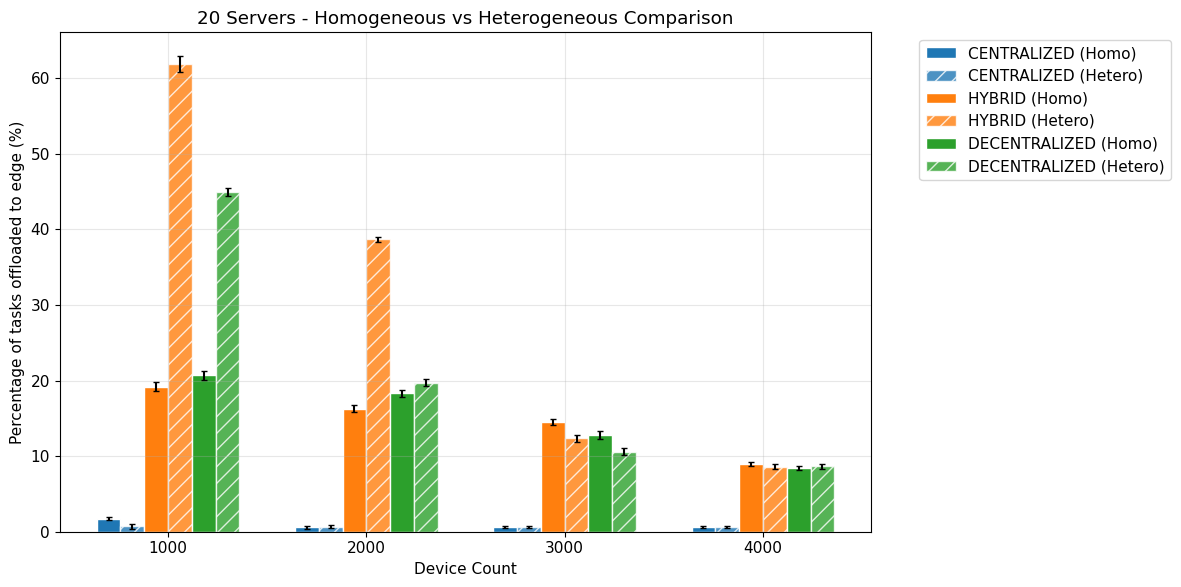

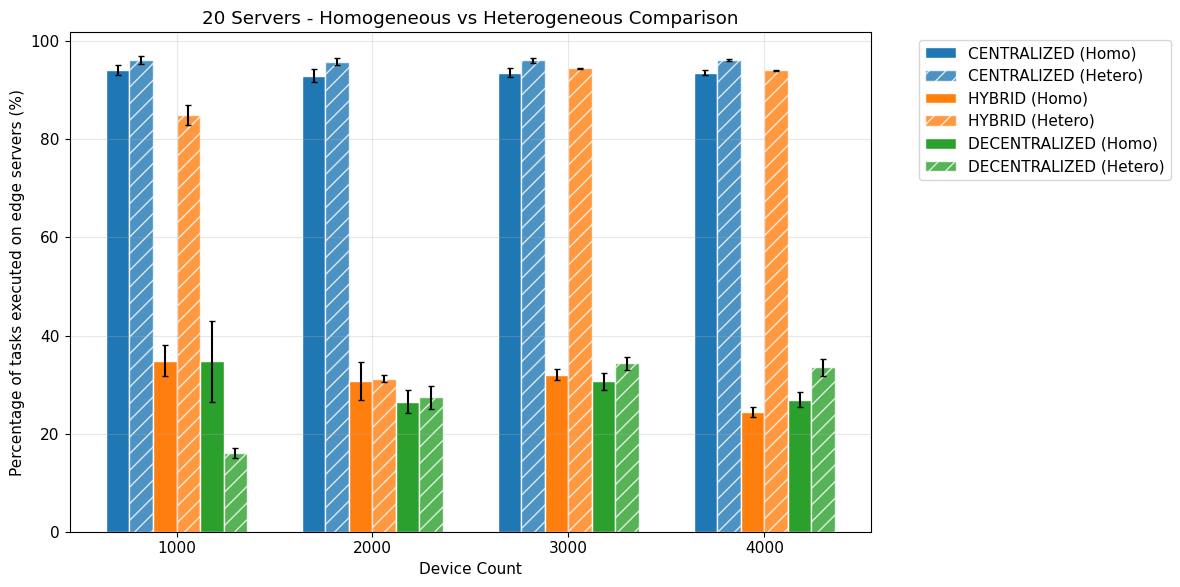

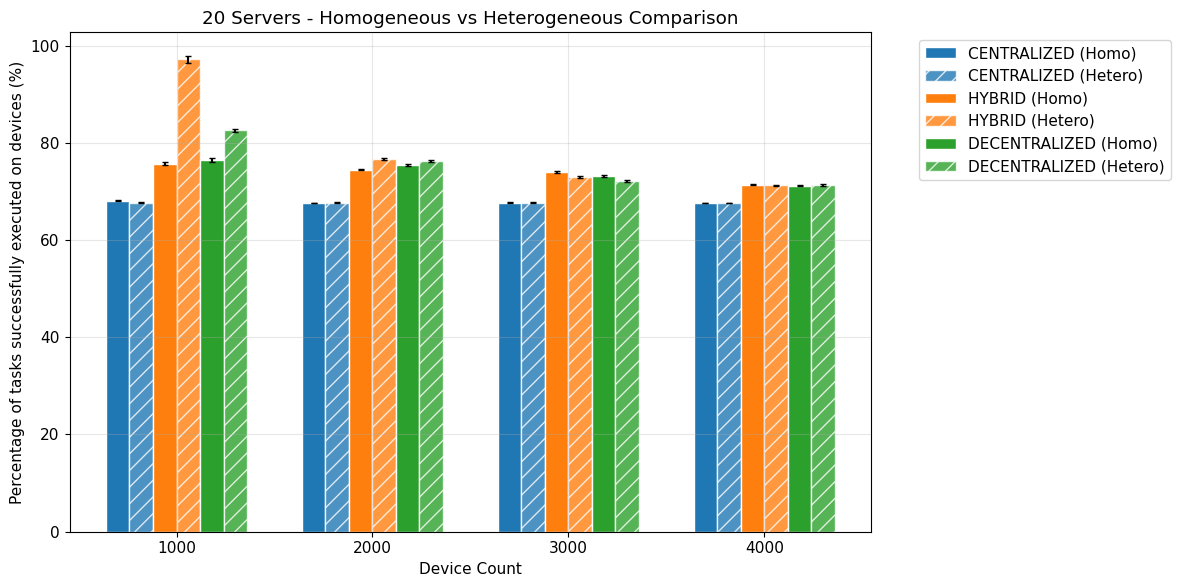

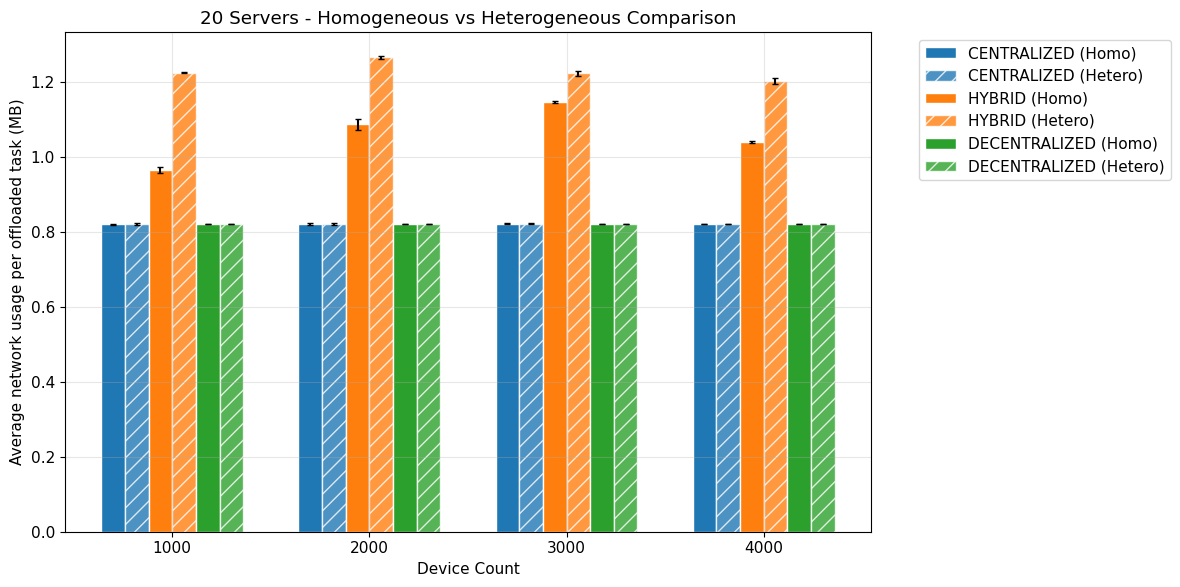

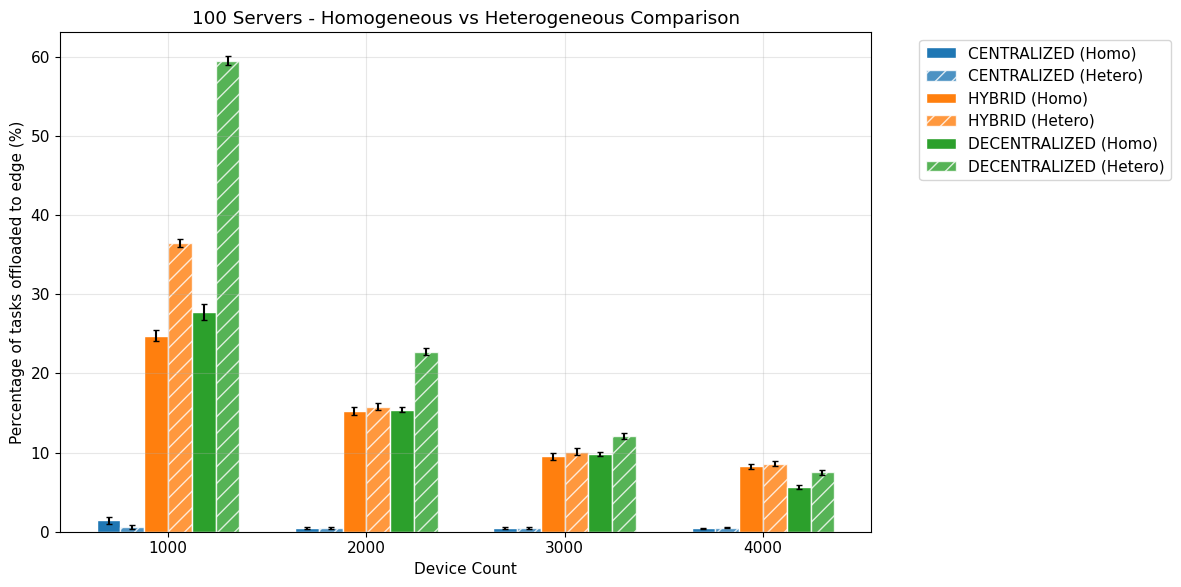

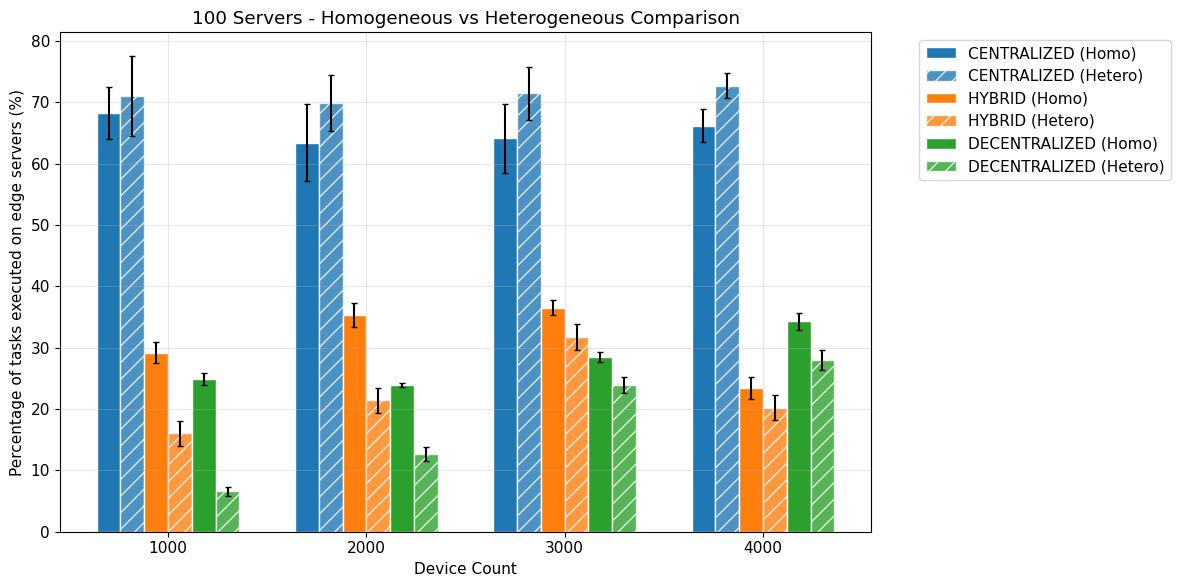

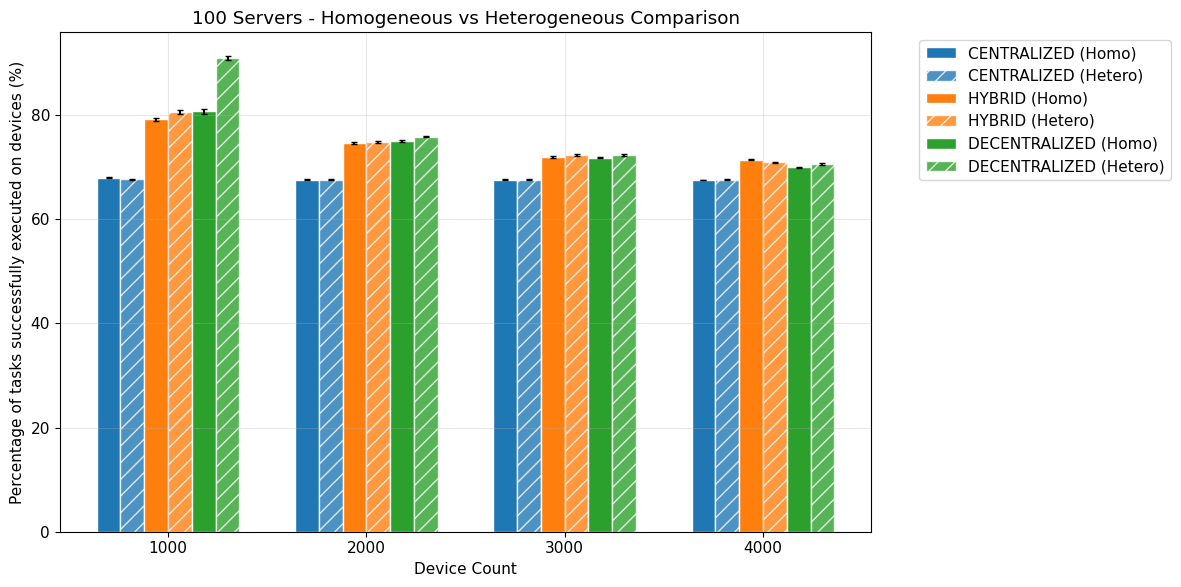

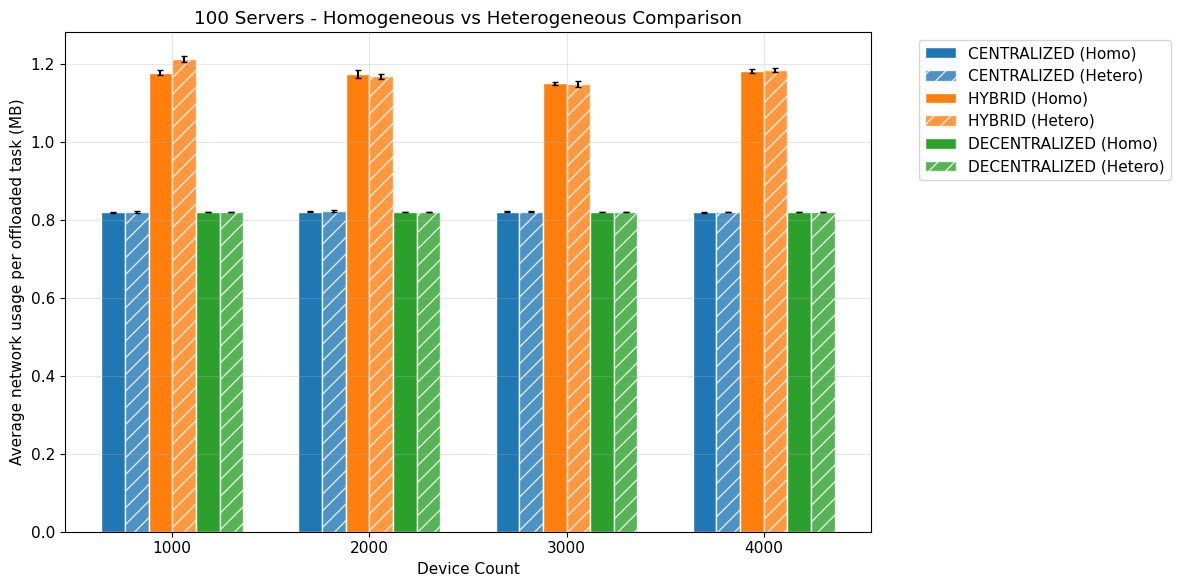

In [14]:
def plot_metric_comparison(data, server_count, metric_key, metric_label, title_suffix, log_scale=False):
    homo_key = f'homo_{server_count}'
    hetero_key = f'hetero_{server_count}'
    
    device_counts = [1000, 2000, 3000, 4000]
    topo_map = {'C': 'CENTRALIZED', 'H': 'HYBRID', 'D': 'DECENTRALIZED'}
    colors = {'CENTRALIZED': 'tab:blue', 'HYBRID': 'tab:orange', 'DECENTRALIZED': 'tab:green'}
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(device_counts))
    width = 0.12  # width of a single bar
    num_bars = 6
    total_width = width * num_bars
    
    for i, topo_letter in enumerate(['C', 'H', 'D']):
        topo_name = topo_map[topo_letter]
        
        for j, (config_name, config_key, hatch, alpha) in enumerate([('Homo', homo_key, None, 1.0), ('Hetero', hetero_key, '//', 0.8)]):
            folder_data = data[config_key].get(topo_letter, {})
            
            means = []
            stds = []
            
            for dc in device_counts:
                vals = []
                for inner_topo, devices in folder_data.items():
                    samples = devices.get(dc, [])
                    vals.extend([s.get(metric_key, 0) for s in samples])
                
                if vals:
                    means.append(np.mean(vals))
                    stds.append(np.std(vals) if len(vals) > 1 else 0)
                else:
                    means.append(0)
                    stds.append(0)
            
            pos = x - (total_width / 2) + (i * 2 + j) * width + width/2
            label = f"{topo_name} ({config_name})"
            hatch_pattern = hatch if hatch else ''
            
            ax.bar(pos, means, width, yerr=stds, label=label, 
                   color=colors[topo_name], hatch=hatch_pattern, alpha=alpha, edgecolor='white', capsize=2)
    
    ax.set_xlabel('Device Count')
    ax.set_ylabel(metric_label)
    ax.set_title(f'{title_suffix} - Homogeneous vs Heterogeneous Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(device_counts)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    if log_scale:
        ax.set_yscale('log')
    
    plt.tight_layout()
    return fig

metrics_to_plot = [
    ('offloadRate', 'Percentage of tasks offloaded to edge (%)'),
    ('edgeSuccessRate', 'Percentage of tasks executed on edge servers (%)'),
    ('deviceSuccessRate', 'Percentage of tasks successfully executed on devices (%)'),
    ('avgNetUsage', 'Average network usage per offloaded task (MB)')
]

for s_count in ['20', '100']:
    for m_key, m_label in metrics_to_plot:
        fig = plot_metric_comparison(data, s_count, m_key, m_label, f'{s_count} Servers')
        plt.savefig(f'{m_key}_comparison_{s_count}servers.pdf', bbox_inches='tight')
        plt.show()


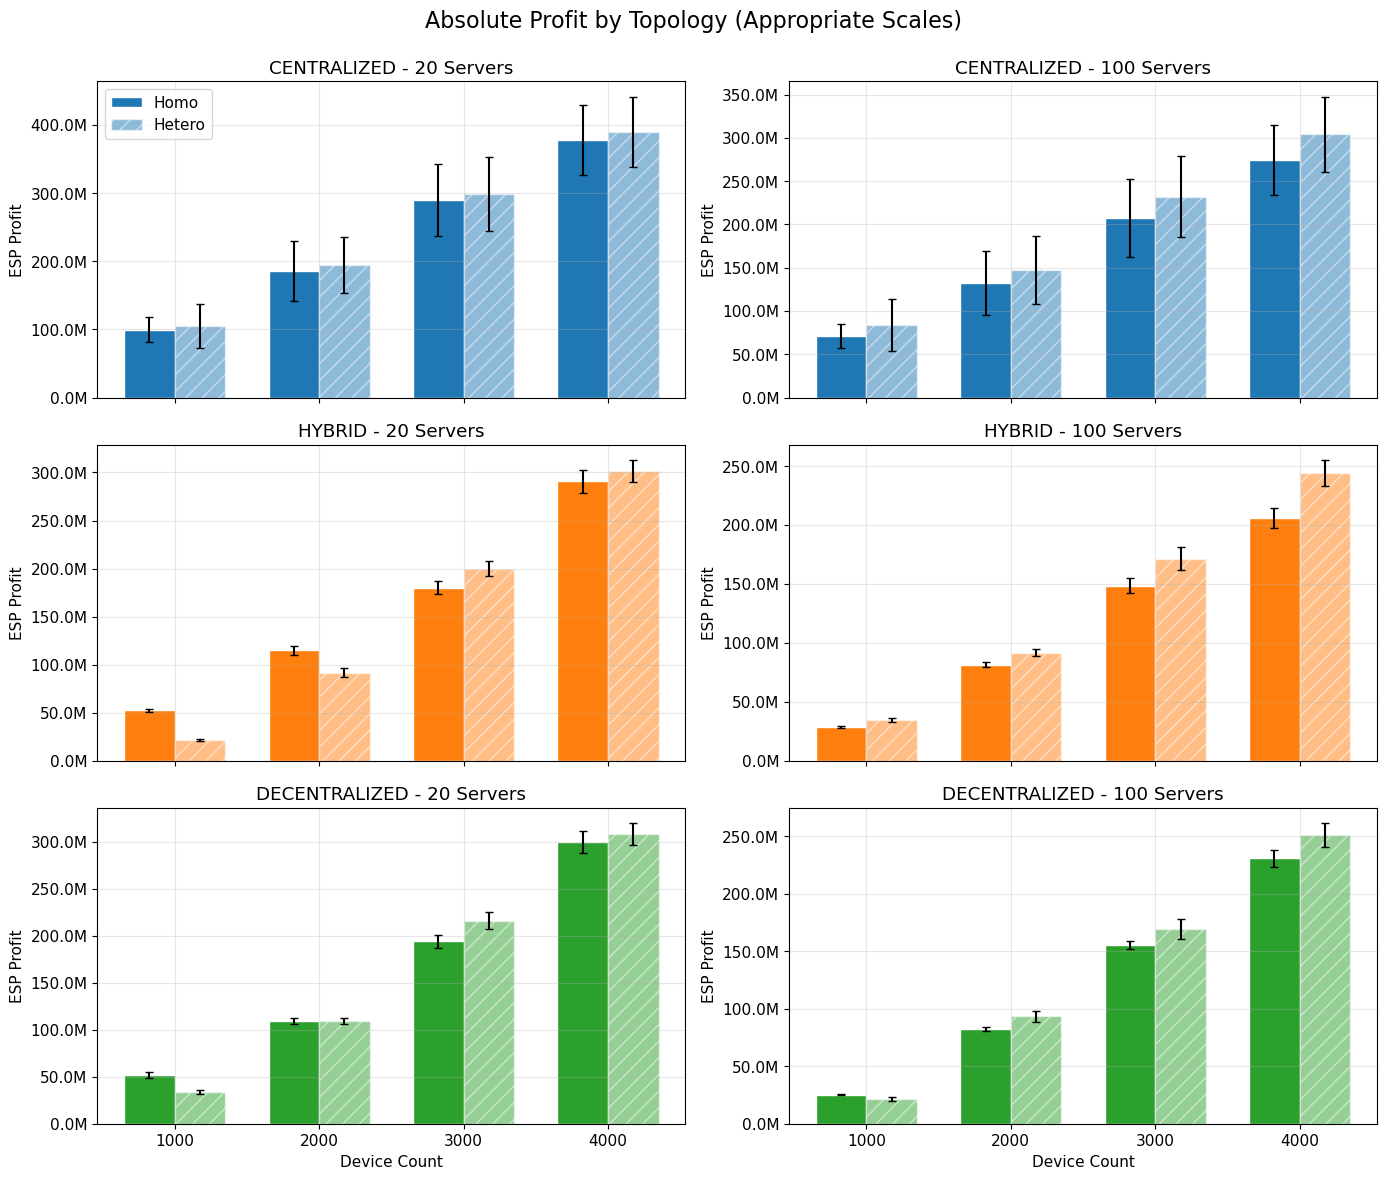

In [15]:
def plot_absolute_profit_topology_separated(data):
    device_counts = [1000, 2000, 3000, 4000]
    topologies = ['C', 'H', 'D']
    topo_map = {'C': 'CENTRALIZED', 'H': 'HYBRID', 'D': 'DECENTRALIZED'}
    server_counts = ['20', '100']
    colors = {'C': 'tab:blue', 'H': 'tab:orange', 'D': 'tab:green'}
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
    
    x = np.arange(len(device_counts))
    width = 0.35
    
    for row_idx, topo in enumerate(topologies):
        topo_name = topo_map[topo]
        color = colors[topo]
        
        for col_idx, s_count in enumerate(server_counts):
            ax = axes[row_idx, col_idx]
            
            homo_key = f'homo_{s_count}'
            hetero_key = f'hetero_{s_count}'
            
            # Retrieve Homo Data
            homo_folder = data.get(homo_key, {}).get(topo, {})
            homo_means = []
            homo_stds = []
            for dc in device_counts:
                vals = []
                for inner_topo, devices in homo_folder.items():
                    samples = devices.get(dc, [])
                    vals.extend([s.get('cumulativeReturn', 0) for s in samples])
                if vals:
                    homo_means.append(np.mean(vals))
                    homo_stds.append(np.std(vals) if len(vals) > 1 else 0)
                else:
                    homo_means.append(0)
                    homo_stds.append(0)
                    
            # Retrieve Hetero Data
            hetero_folder = data.get(hetero_key, {}).get(topo, {})
            hetero_means = []
            hetero_stds = []
            for dc in device_counts:
                vals = []
                for inner_topo, devices in hetero_folder.items():
                    samples = devices.get(dc, [])
                    vals.extend([s.get('cumulativeReturn', 0) for s in samples])
                if vals:
                    hetero_means.append(np.mean(vals))
                    hetero_stds.append(np.std(vals) if len(vals) > 1 else 0)
                else:
                    hetero_means.append(0)
                    hetero_stds.append(0)
            
            ax.bar(x - width/2, homo_means, width, yerr=homo_stds, label='Homo', 
                   color=color, alpha=1.0, edgecolor='white', capsize=3)
            ax.bar(x + width/2, hetero_means, width, yerr=hetero_stds, label='Hetero', 
                   color=color, alpha=0.5, hatch='//', edgecolor='white', capsize=3)
            
            ax.set_title(f'{topo_name} - {s_count} Servers')
            ax.set_ylabel('ESP Profit')
            ax.set_xticks(x)
            ax.set_xticklabels(device_counts)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, p: f'{val/1e6:.1f}M'))
            if row_idx == 0 and col_idx == 0:
                ax.legend()
            
            if row_idx == 2:
                ax.set_xlabel('Device Count')
                
    fig.suptitle('Absolute Profit by Topology (Appropriate Scales)', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    return fig

fig_abs_profit = plot_absolute_profit_topology_separated(data)
plt.savefig('absolute_profit_topology_separated.pdf', bbox_inches='tight')
plt.show()
